# Clusterização de Municípios Brasileiros — Avaliação Final e Conclusão

**Objetivo:** treinar o modelo final escolhido na comparação (`03_Comparacao_Modelos`) — **KPrototypes com k=2** — usando todos os municípios disponíveis, interpretar o perfil de cada cluster e salvar o modelo para uso futuro.

A validação de desempenho e generalização (treino/teste) já foi feita nos notebooks anteriores. Para o modelo final "de produção", usamos a base completa, maximizando a quantidade de informação usada no ajuste.

## 1. Imports

In [1]:
import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from kmodes.kprototypes import KPrototypes
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

PASTA_REPORTS = "../reports"
PASTA_MODELS = "../models"
PASTA_DATA = "../data"
os.makedirs(PASTA_REPORTS, exist_ok=True)
os.makedirs(PASTA_MODELS, exist_ok=True)

## 2. Carregar e preparar os dados (base completa)

In [2]:
df = pd.read_csv(f"{PASTA_DATA}/municipios_brasil.csv")
df = df.dropna().reset_index(drop=True)

COLUNAS_NUMERICAS = [
    "populacao",
    "pib_total_mil_reais",
    "vab_agropecuaria_mil_reais",
    "vab_industria_mil_reais",
    "vab_servicos_mil_reais",
    "vab_adm_publica_mil_reais",
    "pib_per_capita_reais",
]

# Mesma limpeza usada em 02/03: VAB da indústria negativo (peculiaridade do IBGE) -> 0
df[COLUNAS_NUMERICAS] = df[COLUNAS_NUMERICAS].clip(lower=0)

print("Total de municípios:", len(df))
df.head()

Total de municípios: 5570


,codigo_municipio,municipio,uf_sigla,uf_nome,regiao,mesorregiao,microrregiao,populacao,pib_total_mil_reais,vab_adm_publica_mil_reais,vab_agropecuaria_mil_reais,vab_industria_mil_reais,vab_servicos_mil_reais,pib_per_capita_reais
0,1100015,Alta Floresta D'Oeste,RO,Rondônia,Norte,Leste Rondoniense,Cacoal,22516.0,734467.0,173122.0,311469.0,27845.0,172435.0,32619.781489
1,1100023,Ariquemes,RO,Rondônia,Norte,Leste Rondoniense,Ariquemes,111148.0,3211294.0,782306.0,293001.0,407675.0,1307977.0,28892.053838
2,1100031,Cabixi,RO,Rondônia,Norte,Leste Rondoniense,Colorado do Oeste,5067.0,238414.0,46579.0,136659.0,8117.0,35866.0,47052.299191
3,1100049,Cacoal,RO,Rondônia,Norte,Leste Rondoniense,Cacoal,86416.0,2792506.0,629109.0,341315.0,236801.0,1200654.0,32314.687095
4,1100056,Cerejeiras,RO,Rondônia,Norte,Leste Rondoniense,Colorado do Oeste,16088.0,743062.0,123365.0,151690.0,27433.0,308668.0,46187.344605


**Nota:** aqui usamos os **5.570 municípios completos** (treino + teste dos notebooks anteriores), não só os 4.456 do treino — para o modelo final "de produção" queremos aproveitar 100% do dado disponível, já que a validação de generalização já foi feita separadamente em `02_Baseline` e `03_Comparacao_Modelos`. A limpeza (remoção do município sem dado e `clip` do VAB industrial negativo) é repetida de forma idêntica, garantindo consistência com os notebooks anteriores.

In [3]:
scaler = StandardScaler()
X_num = scaler.fit_transform(np.log1p(df[COLUNAS_NUMERICAS]))

X_mix = np.hstack([X_num, df[["regiao"]].astype(str).values]).astype(object)
IDX_CATEGORICA = X_num.shape[1]  # última coluna = regiao

print("X_mix:", X_mix.shape)

X_mix: (5570, 8)


## 3. Treinar o modelo final (KPrototypes, k=2)

In [4]:
K_FINAL = 2

kprototypes_final = KPrototypes(n_clusters=K_FINAL, init="Huang", n_init=5, random_state=RANDOM_STATE, verbose=0)
labels = kprototypes_final.fit_predict(X_mix, categorical=[IDX_CATEGORICA])

df["cluster"] = labels

sil = silhouette_score(X_num, labels)
ch = calinski_harabasz_score(X_num, labels)
db = davies_bouldin_score(X_num, labels)

print(f"Custo do modelo: {kprototypes_final.cost_:.1f}")
print(f"Silhouette: {sil:.3f} | Calinski-Harabasz: {ch:.1f} | Davies-Bouldin: {db:.3f}")
print("\nTamanho dos clusters:")
print(df["cluster"].value_counts().sort_index())

Custo do modelo: 23017.4
Silhouette: 0.412 | Calinski-Harabasz: 4633.2 | Davies-Bouldin: 0.973

Tamanho dos clusters:
cluster
0    3767
1    1803
Name: count, dtype: int64


**Leitura estatística:** o silhouette de 0,412 fica entre os valores de treino (0,413) e teste (0,407) obtidos no notebook `03` para o mesmo algoritmo — coerente, já que este modelo é treinado na união dos dois conjuntos. O custo de 23.017,4 **não é diretamente comparável** ao custo de 18.369,4 visto no notebook `03`: lá o KPrototypes foi ajustado em 4.456 municípios, aqui em 5.570 (25% a mais de pontos, logo mais termos somados no custo total).

Os clusters saem com 3.767 (67,6%) e 1.803 (32,4%) municípios. Note que a numeração dos clusters (0 e 1) é **arbitrária** — ela depende da inicialização aleatória dos centróides e pode trocar de um treinamento para o outro. Aqui, o cluster 0 é o *menor* em porte (o oposto do que aconteceu no baseline do notebook `02`, onde o cluster 0 era o maior) — por isso a interpretação de cada cluster deve sempre vir do **perfil numérico** (Seção 5), nunca do número do rótulo em si.

## 4. Visualizar os clusters (PCA 2D)

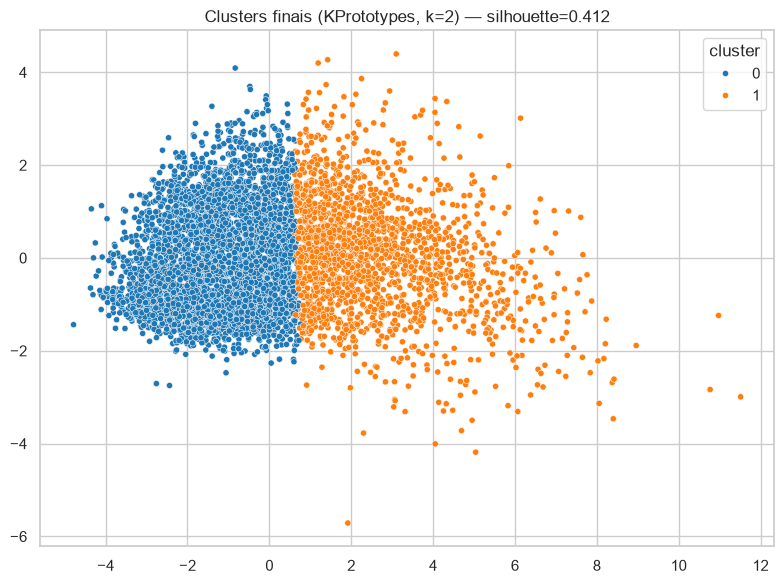

In [5]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_num)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["cluster"], palette="tab10", s=20)
plt.title(f"Clusters finais (KPrototypes, k={K_FINAL}) — silhouette={sil:.3f}")
plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/final_pca_clusters.png", dpi=120)
plt.show()

**Leitura estatística:** as 2 componentes principais explicam 89,3% da variância (69,9% na primeira componente, sozinha, + 19,3% na segunda) — praticamente idêntico aos 89,1% vistos no baseline (`02`), como esperado, já que a estrutura de correlação entre as variáveis não muda ao usar a base completa. A primeira componente concentrar quase 70% da variância sozinha é o retrato numérico direto do que a EDA já mostrava: existe uma dimensão dominante de "porte econômico" (população, PIB e seus componentes setoriais todos correlacionados) que organiza a maior parte da variação entre municípios.

## 5. Perfil numérico de cada cluster

In [6]:
perfil = df.groupby("cluster")[COLUNAS_NUMERICAS].median()
perfil["n_municipios"] = df["cluster"].value_counts().sort_index()
perfil

,populacao,pib_total_mil_reais,vab_agropecuaria_mil_reais,vab_industria_mil_reais,vab_servicos_mil_reais,vab_adm_publica_mil_reais,pib_per_capita_reais,n_municipios
cluster,,,,,,,,
0,7305.0,150571.0,30368.0,7706.0,35648.0,40341.0,17228.031954,3767
1,36271.0,1224548.0,108635.0,227130.0,404482.0,194283.0,37459.114296,1803


**Leitura estatística — validação cruzada com o baseline:**

| Variável | Cluster 1 / Cluster 0 (aqui, base completa) | Razão equivalente no baseline (`02`) |
|---|---:|---:|
| `vab_industria_mil_reais` | 29,5x | 29,8x |
| `vab_servicos_mil_reais` | 11,3x | 11,0x |
| `pib_total_mil_reais` | 8,1x | 7,9x |
| `populacao` | 5,0x | 5,0x |
| `vab_adm_publica_mil_reais` | 4,8x | 4,7x |
| `vab_agropecuaria_mil_reais` | 3,6x | 3,6x |
| `pib_per_capita_reais` | 2,2x | 2,2x |

As razões entre os clusters são **quase idênticas** às encontradas no notebook `02` (baseline, treinado só com 80% dos dados, sem a região como feature). Essa é uma validação forte: adicionar 25% mais dados e a variável `regiao` ao ajuste não muda a natureza da divisão — o KPrototypes converge para essencialmente o mesmo padrão em ambos os experimentos, o que reforça que a divisão em 2 grupos captura algo estrutural nos dados, não uma peculiaridade de uma amostra específica.

Mais uma vez, a maior razão é a de `vab_industria` (~30x, muito acima da razão de população, 5x) — o cluster maior/mais rico concentra desproporcionalmente a atividade industrial — e a menor é `pib_per_capita` (2,2x), confirmando que renda por habitante varia bem menos entre os grupos do que as variáveis de escala absoluta.

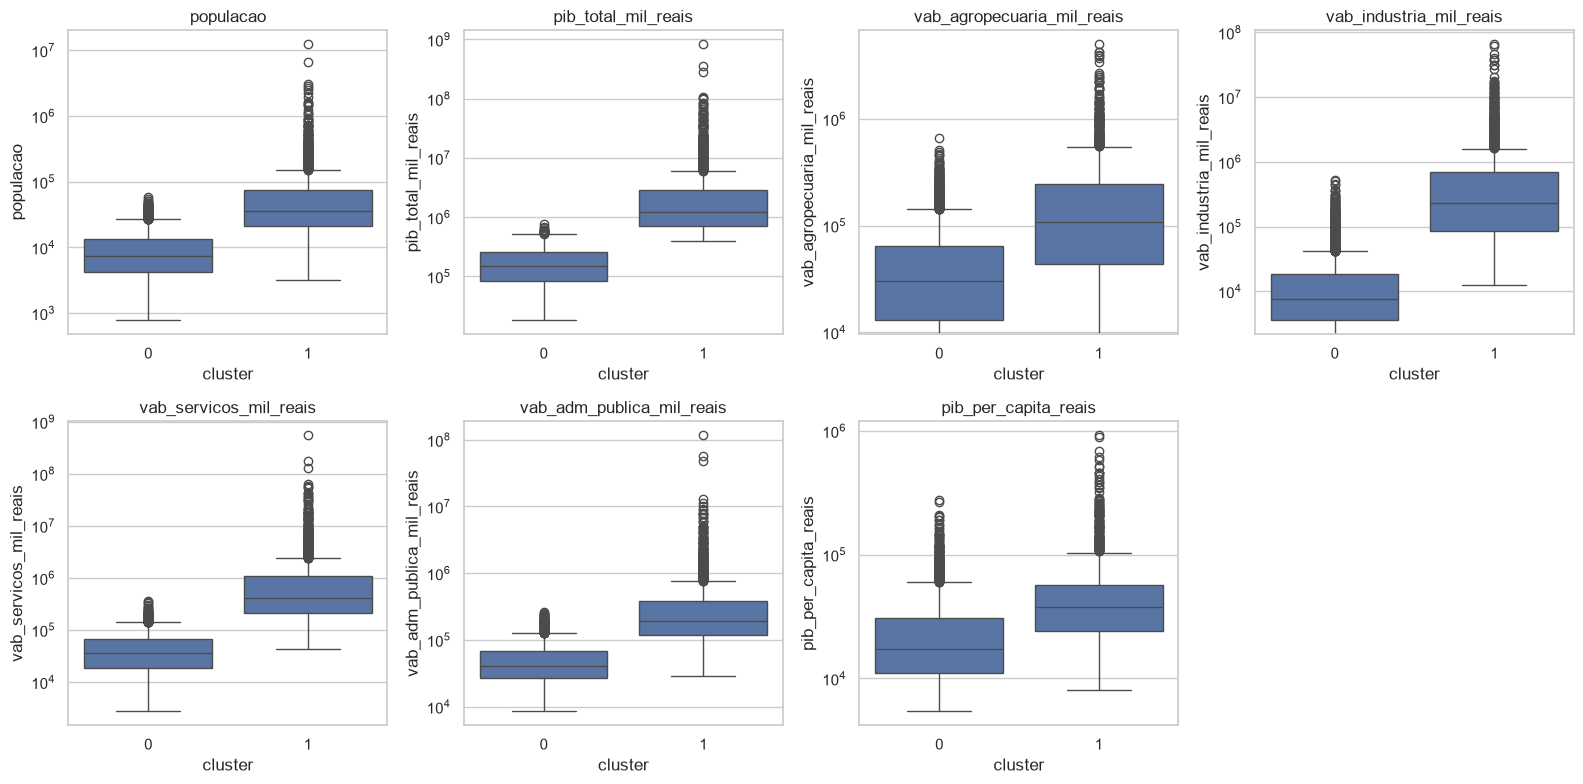

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.ravel(), COLUNAS_NUMERICAS):
    sns.boxplot(data=df, x="cluster", y=col, ax=ax)
    ax.set_yscale("log")
    ax.set_title(col)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/final_boxplots_por_cluster.png", dpi=120)
plt.show()

**Leitura estatística:** o grau de separação entre as caixas (mesmo em escala log) varia bastante de variável para variável. `vab_industria_mil_reais` mostra a separação mais limpa — a caixa do cluster 0 (~10⁴ a 2×10⁴) não encosta na caixa do cluster 1 (~10⁵ a 7×10⁵), sem sobreposição —, o que é esperado dado o gap de ~30x visto na tabela de perfil. Já `vab_agropecuaria_mil_reais` e `pib_per_capita_reais` são as variáveis com **mais sobreposição visual**: a ponta superior da caixa/bigode do cluster 0 já invade a faixa inferior da caixa do cluster 1 — coerente com serem as duas variáveis de menor razão entre clusters (3,6x e 2,2x) e confirmando, de forma visual, o que a EDA já indicava sobre `pib_per_capita` ser relativamente independente do porte do município.

Em todas as variáveis, ainda restam bastante outliers (círculos acima do bigode superior) **dentro de cada cluster** — a clusterização separa dois grandes regimes de porte, mas não elimina a assimetria residual dentro de cada grupo (há "grandes" e "muito grandes" dentro do próprio cluster 1, por exemplo). Isso é esperado: k=2 captura a divisão dominante nos dados, não todas as nuances de escala.

## 6. Perfil geográfico de cada cluster

In [8]:
# Distribuição percentual de cada região dentro de cada cluster
tabela_regiao = pd.crosstab(df["cluster"], df["regiao"], normalize="index").round(3) * 100
tabela_regiao

regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
cluster,,,,,
0,6.6,38.3,8.0,26.9,20.1
1,12.2,19.4,8.2,36.3,24.0


**Leitura estatística — qual região puxa mais para qual cluster:**

| Região | Cluster 0 / Cluster 1 (razão de representatividade) | Leitura |
|---|---:|---|
| Centro-Oeste | 0,54x | mais que o dobro de representação relativa no cluster 1 (maior porte) |
| Sudeste | 0,74x | também sobre-representado no cluster 1 |
| Sul | 0,84x | levemente sobre-representado no cluster 1 |
| Norte | 0,98x | praticamente neutro — sem viés relevante entre clusters |
| Nordeste | 1,97x | quase o dobro de representação relativa no cluster 0 (menor porte) |

O Nordeste é a região com o viés mais forte para o cluster de menor porte, e o Centro-Oeste é a que mais puxa para o cluster maior/mais rico — mesmo tendo, segundo a EDA (`01`), bem menos municípios em números absolutos (468 contra os 1.794 do Nordeste). O Norte se destaca por ser a **única região sem viés claro** entre os dois clusters (razão quase 1:1) — condizente com o achado da EDA de que o Norte tem população mediana relativamente alta, mas PIB per capita mediano baixo, uma combinação que não empurra claramente seus municípios para nenhum dos dois grupos.

In [9]:
# Os 10 maiores municípios (por população) de cada cluster, para dar nomes reais aos grupos
for c in sorted(df["cluster"].unique()):
    print(f"\nCluster {c} — exemplos (maiores em população):")
    print(
        df[df["cluster"] == c]
        .nlargest(10, "populacao")[["municipio", "uf_sigla", "populacao", "pib_per_capita_reais"]]
        .to_string(index=False)
    )


Cluster 0 — exemplos (maiores em população):
               municipio uf_sigla  populacao  pib_per_capita_reais
           Vargem Grande       MA    57813.0           7497.846505
                   Barra       BA    54225.0           7935.122176
  Brejo da Madre de Deus       PE    51696.0           8924.423553
                Macaúbas       BA    50481.0           8528.911868
                Araioses       MA    47095.0           6004.225502
São Gabriel da Cachoeira       AM    47031.0           8995.237184
          Augusto Corrêa       PA    46937.0           7739.416665
             Xique-Xique       BA    46562.0           9896.847214
               São Bento       MA    45989.0           6787.710105
              Maragogipe       BA    44902.0           8957.641085

Cluster 1 — exemplos (maiores em população):
     municipio uf_sigla  populacao  pib_per_capita_reais
     São Paulo       SP 12396372.0          66872.851750
Rio de Janeiro       RJ  6775561.0          53077.914582


**Leitura estatística:** a fronteira entre os clusters é surpreendentemente "limpa" em termos de população: o **maior** município do cluster 0 (Vargem Grande - MA, 57.813 hab.) é **27x menor** que o **menor** entre os 10 maiores do cluster 1 (Goiânia - GO, 1.555.626 hab.) — não há uma zona cinzenta de cidades médias disputada entre os dois grupos nesta lista. Isso é coerente com o cluster 1 ser essencialmente "toda capital e metrópole relevante do país", enquanto o maior município do cluster 0 ainda é uma cidade de porte médio-baixo pelos padrões nacionais. Vale notar também a diversidade de PIB per capita dentro do próprio cluster 1 — de R$ 21.715 (Salvador) a R$ 92.732 (Brasília), mais de 4x de variação —, lembrando que "grande porte" não significa "renda per capita uniforme", só maior porte econômico absoluto.

## 7. Salvar modelo final e dataset com clusters

In [10]:
joblib.dump(scaler, f"{PASTA_MODELS}/final_scaler.joblib")
joblib.dump(kprototypes_final, f"{PASTA_MODELS}/final_kprototypes.joblib")

df.to_csv(f"{PASTA_REPORTS}/municipios_clusterizados.csv", index=False)

print("Modelo, scaler e dataset com clusters salvos.")
print(f"- {PASTA_MODELS}/final_scaler.joblib")
print(f"- {PASTA_MODELS}/final_kprototypes.joblib")
print(f"- {PASTA_REPORTS}/municipios_clusterizados.csv")

Modelo, scaler e dataset com clusters salvos.
- ../models/final_scaler.joblib
- ../models/final_kprototypes.joblib
- ../reports/municipios_clusterizados.csv


**Nota:** o `scaler` é salvo junto com o modelo porque é parte indispensável do pipeline — qualquer município novo precisa passar pelo mesmo `log1p` + padronização (ajustada aqui, nesta base) antes de ser classificado pelo KPrototypes; salvar só o modelo, sem o scaler, tornaria o resultado não reprodutível. O `municipios_clusterizados.csv` guarda o dataset completo com a coluna `cluster` adicionada, pronto para ser consumido por outras análises sem precisar re-treinar nada.

## 8. Conclusão do projeto

O modelo final (**KPrototypes, k=2**, treinado com as 7 variáveis numéricas + a região) dividiu os 5.570 municípios brasileiros em dois grupos claramente interpretáveis (silhouette = 0.412, Davies-Bouldin = 0.97, Calinski-Harabasz = 4.633):

**Cluster 0 — "Municípios de menor porte" (3.767 municípios, 67,6% do total)**
- População mediana: ~7.300 habitantes
- PIB total mediano: ~R$ 150,6 milhões
- PIB per capita mediano: ~R$ 17.230
- Concentração regional: Nordeste (38,3%), Sudeste (26,9%), Sul (20,1%), Norte (8,0%), Centro-Oeste (6,6%)

**Cluster 1 — "Grandes centros urbanos e econômicos" (1.803 municípios, 32,4% do total)**
- População mediana: ~36.300 habitantes (5x maior que o cluster 0)
- PIB total mediano: ~R$ 1,22 bilhão (8x maior)
- PIB per capita mediano: ~R$ 37.460 (mais que o dobro)
- Concentração regional: Sudeste (36,3%), Sul (24,0%), Nordeste (19,4%), Centro-Oeste (12,2%), Norte (8,2%)
- Inclui todas as grandes capitais e metrópoles (São Paulo, Rio de Janeiro, Brasília, Salvador, Fortaleza, Belo Horizonte, Manaus, Curitiba, Recife, Goiânia, entre outras)

**Leitura socioeconômica:** a clusterização recupera, de forma não supervisionada, um padrão bem documentado da geografia econômica brasileira — municípios maiores e mais ricos por habitante concentram-se relativamente mais nas regiões Sudeste, Sul e Centro-Oeste, enquanto municípios menores e de menor PIB per capita são proporcionalmente mais comuns no Nordeste e Norte.

**Resumo do percurso do projeto:**
1. `01_EDA`: identificou forte assimetria nas variáveis (poucos municípios concentram população/PIB), um valor negativo anômalo (VAB indústria) e ausência de dados em 1 município.
2. `02_Baseline`: KMeans com `k=2` (maior silhouette), validado com divisão treino/teste antes de qualquer transformação.
3. `03_Comparacao_Modelos`: comparação de 7 algoritmos (KMeans, Agglomerative, DBSCAN, HDBSCAN, OPTICS, KModes, KPrototypes) mostrou que os municípios brasileiros formam um gradiente contínuo de porte/renda melhor capturado por métodos de particionamento (KMeans/Agglomerative/KPrototypes) do que por métodos de densidade (DBSCAN/HDBSCAN/OPTICS, que geraram alta fração de ruído).
4. `04_Avaliacao_Conclusao` (este notebook): modelo final KPrototypes treinado na base completa, com clusters interpretáveis e alinhados a um fenômeno socioeconômico real.

**Limitações e próximos passos:** o resultado com k=2 é robusto, mas grosseiro (duas categorias apenas). Trabalhos futuros podem explorar granularidade maior (k=3-5), variáveis adicionais (ex.: indicadores de educação/saúde por município) e comparação com o Índice de Desenvolvimento Humano Municipal (IDHM) do Atlas Brasil (IPEA/PNUD), que também é catalogado no Portal Brasileiro de Dados Abertos.